In [310]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [311]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\Export.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10928 entries, 0 to 10927
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  10928 non-null  str  
 1   Message  10928 non-null  str  
 2   Status   10928 non-null  str  
dtypes: str(3)
memory usage: 256.3 KB


In [312]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [313]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-08-24 19:07:55.490 Last fuel report fs02:  2026-08-24 19:04:40.117


In [314]:
values_dates_fs01.info()
values_dates_fs02.info()

<class 'pandas.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     5462 non-null   int64
 1   date      5462 non-null   str  
 2   raw data  5462 non-null   str  
dtypes: int64(1), str(2)
memory usage: 128.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 2221 entries, 0 to 2220
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     2221 non-null   int64
 1   date      2221 non-null   str  
 2   raw data  2221 non-null   str  
dtypes: int64(1), str(2)
memory usage: 52.2 KB


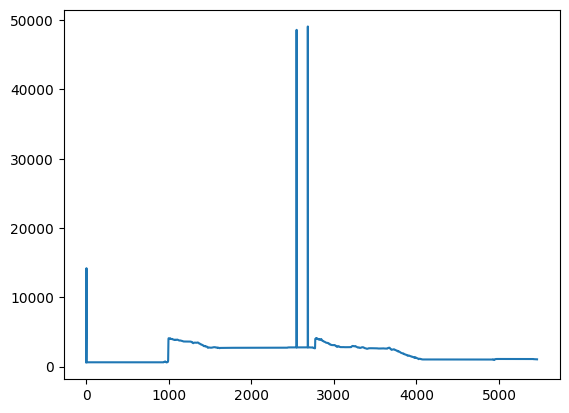

In [315]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

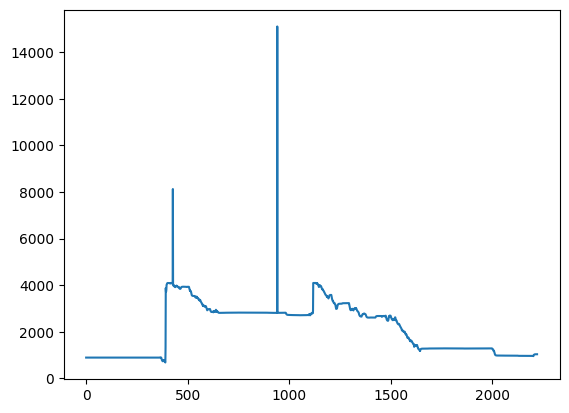

In [316]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [317]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,0])>4095:
        print(values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[1,2][32:44],values_dates_fs01_ordered.iloc[i,0])

0x25252100230006086948706015659226081417582900013E01421A0210A9BE03015518 -> 260814175829 4098
0x25252100230008086948706015659226081417582900013E01600082102301E20015D8 -> 260814175829 4226
0x252521002D000A086948706015659226081417582900013E01411A0210A9BE0301552500F2940000010068994A -> 260814175829 4098
0x2525210023000C086948706015659226081417582900013E0184A47A37C4D07DC39488 -> 260814175829 14202
0x25252100210E28086948706015659226082019565900013E01071AD8BD0AC2A91F -> 260814175829 48600
0x25252100210EE5086948706015659226082023550000013E0107D5BFBF0EB4A901 -> 260814175829 49087


In [318]:
values_dates_fs01_ordered.info()

<class 'pandas.DataFrame'>
Index: 5462 entries, 0 to 5461
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     5462 non-null   int64
 1   date      5462 non-null   str  
 2   raw data  5462 non-null   str  
dtypes: int64(1), str(2)
memory usage: 170.7 KB


In [319]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>260821124000:
        print(values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[i,2][32:44],values_dates_fs01_ordered.iloc[i,0])

0x25252100200F5F086948706015659226082112402501013E010716500A08A549 -> 260821124025 2640
0x25252100200F60086948706015659226082112421000013E010716600A01A651 -> 260821124210 2656
0x25252100200F61086948706015659226082112435500013E010716AF0BFBBA19 -> 260821124355 2991
0x25252100200F63086948706015659226082112454000013E0107161D0FDBF1B6 -> 260821124540 3869
0x25252100200F64086948706015659226082112472500013E010716A00F0BFAC2 -> 260821124725 4000
0x25252100200F66086948706015659226082112491000013E010716B00F0AFB60 -> 260821124910 4016
0x25252100200F67086948706015659226082112505500013E010716A90F95FA4E -> 260821125055 4009
0x25252100200F68086948706015659226082112524000013E010716B40F47FB7C -> 260821125240 4020
0x25252100200F6A086948706015659226082112542500013E010716C20F22FCFB -> 260821125425 4034
0x25252100200F6B086948706015659226082112561000013E010717CD0FD5FC5B -> 260821125610 4045
0x25252100200F6D086948706015659226082112575501013E010717D00F09FDB5 -> 260821125755 4048
0x25252100200F6E0869487060156592

In [320]:
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>260821124000:
        print(values_dates_fs02_ordered.iloc[i,2],'->',values_dates_fs02_ordered.iloc[i,2][32:44],values_dates_fs02_ordered.iloc[i,0])

0x25252100200F62086948706015659226082112441000013E020714EE0AECAE67 -> 260821124410 2798
0x25252100200F65086948706015659226082112482500013E020714570B7FB5E5 -> 260821124825 2903
0x25252100200F69086948706015659226082112524000013E020715FF0FFFFF14 -> 260821125240 4095
0x25252100200F6C086948706015659226082112565500013E020715FF0FFFFF14 -> 260821125655 4095
0x25252100200F6F086948706015659226082113011001013E020715FF0FFFFF14 -> 260821130110 4095
0x25252100200F73086948706015659226082113052501013E020716FF0FFFFF5A -> 260821130525 4095
0x25252100200F76086948706015659226082113094001013E020717FF0FFFFF97 -> 260821130940 4095
0x25252100200F7A086948706015659226082113135500013E020718FF0FFFFFF8 -> 260821131355 4095
0x25252100200F7D086948706015659226082113181000013E020718FF0FFFFFF8 -> 260821131810 4095
0x25252100200F81086948706015659226082113222500013E020718FF0FFFFFF8 -> 260821132225 4095
0x25252100200F84086948706015659226082113264000013E020719FF0FFFFF35 -> 260821132640 4095
0x25252100200F870869487060156592